Saving aerialimage.jpg to aerialimage.jpg


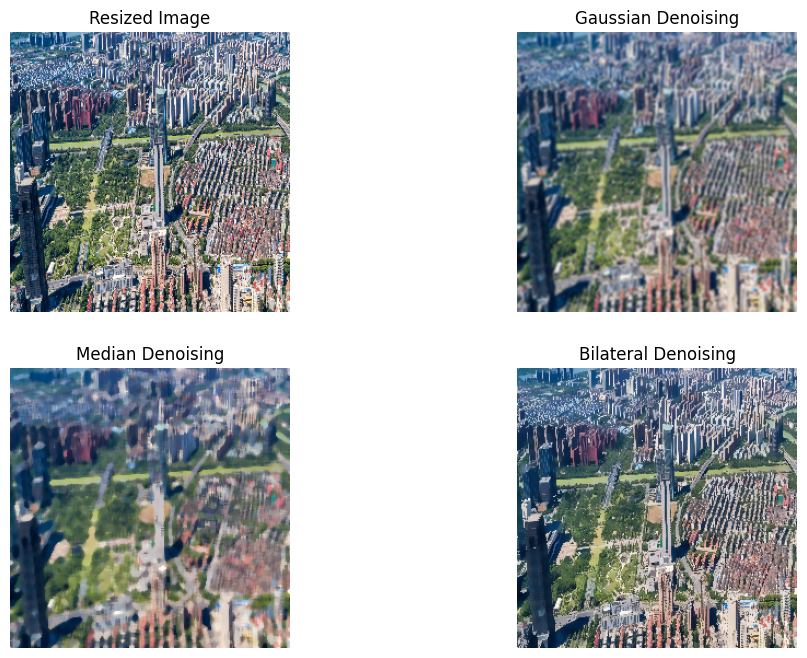

In [5]:
#1q

# Install (if needed)
!pip install opencv-python matplotlib

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# =========================
# 1. Upload Image
# =========================
uploaded = files.upload()

image_path = list(uploaded.keys())[0]

# Read image
img = cv2.imread(image_path)

# Convert to RGB (for display)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# =========================
# 2. Resizing
# =========================
resized = cv2.resize(img_rgb, (256, 256))

# =========================
# 3. Denoising Methods
# =========================

# (a) Gaussian Blur (basic noise removal)
gaussian = cv2.GaussianBlur(resized, (5, 5), 0)

# (b) Median Blur (good for salt & pepper noise)
median = cv2.medianBlur(resized, 5)

# (c) Bilateral Filter (preserves edges)
bilateral = cv2.bilateralFilter(resized, 9, 75, 75)

# =========================
# 4. Visualization
# =========================
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.imshow(resized)
plt.title("Resized Image")
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(gaussian)
plt.title("Gaussian Denoising")
plt.axis('off')

plt.subplot(2,2,3)
plt.imshow(median)
plt.title("Median Denoising")
plt.axis('off')

plt.subplot(2,2,4)
plt.imshow(bilateral)
plt.title("Bilateral Denoising")
plt.axis('off')

plt.show()

In [2]:
!pip install opencv-python opencv-contrib-python scikit-image matplotlib

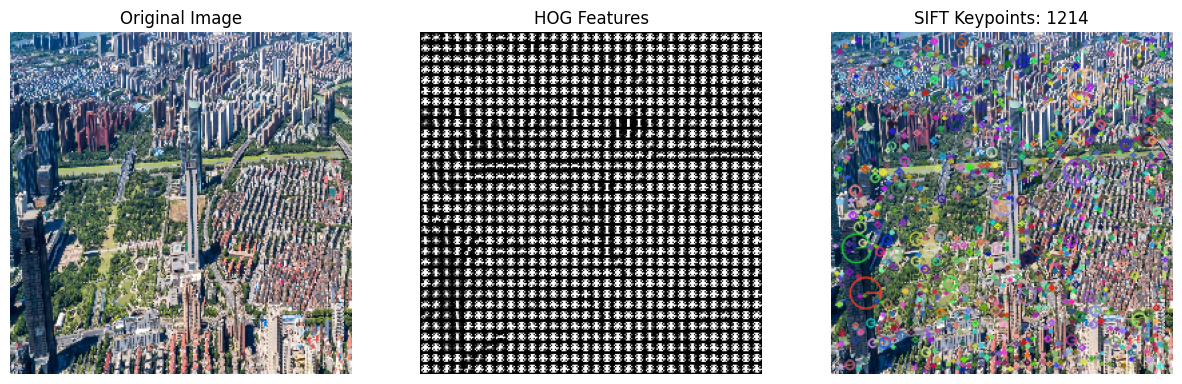

HOG feature vector length: 34596
SIFT descriptor shape: (1214, 128)


In [4]:
#2q


import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import hog
from skimage import exposure
from google.colab.patches import cv2_imshow

# =========================
# 1. Load Image
# =========================
image_path = '/aerialimage.jpg'  # upload your image to Colab
img = cv2.imread(image_path)

# Resize for consistency
img = cv2.resize(img, (256, 256))

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# =========================
# 2. HOG Feature Extraction
# =========================
hog_features, hog_image = hog(
    gray,
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2),
    visualize=True,
    block_norm='L2-Hys'
)

# Rescale HOG image for better visualization
hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))

# =========================
# 3. SIFT Feature Extraction
# =========================
sift = cv2.SIFT_create()

keypoints, descriptors = sift.detectAndCompute(gray, None)

# Draw keypoints
sift_image = cv2.drawKeypoints(
    img, keypoints, None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

# =========================
# 4. Visualization
# =========================
plt.figure(figsize=(15,5))

# Original Image
plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis('off')

# HOG Visualization
plt.subplot(1,3,2)
plt.imshow(hog_image_rescaled, cmap='gray')
plt.title("HOG Features")
plt.axis('off')

# SIFT Keypoints
plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(sift_image, cv2.COLOR_BGR2RGB))
plt.title(f"SIFT Keypoints: {len(keypoints)}")
plt.axis('off')

plt.show()

# =========================
# 5. Print Feature Info
# =========================
print("HOG feature vector length:", len(hog_features))
print("SIFT descriptor shape:", descriptors.shape if descriptors is not None else "None")

Saving img1.jpg to img1.jpg
Saving img2.jpeg to img2.jpeg
Total Matches: 906
Good Matches: 3


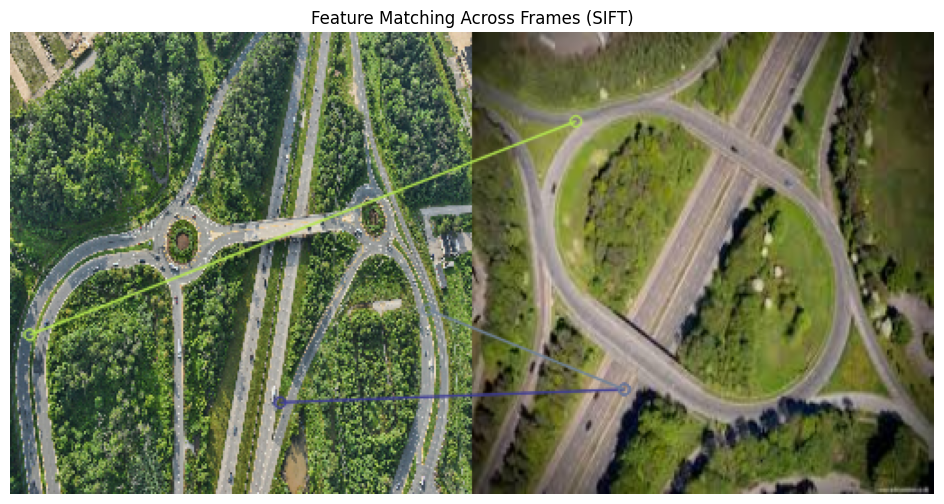

In [6]:
#3q

!pip install opencv-python opencv-contrib-python matplotlib

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# =========================
# 1. Upload Two Frames
# =========================
uploaded = files.upload()

paths = list(uploaded.keys())
img1 = cv2.imread(paths[0])
img2 = cv2.imread(paths[1])

# Resize for consistency
img1 = cv2.resize(img1, (256, 256))
img2 = cv2.resize(img2, (256, 256))

# Convert to grayscale
gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

# =========================
# 2. SIFT Feature Extraction
# =========================
sift = cv2.SIFT_create()

kp1, des1 = sift.detectAndCompute(gray1, None)
kp2, des2 = sift.detectAndCompute(gray2, None)

# =========================
# 3. Feature Matching (BFMatcher)
# =========================
bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=False)

# KNN matching
matches = bf.knnMatch(des1, des2, k=2)

# =========================
# 4. Apply Ratio Test (Lowe's Test)
# =========================
good_matches = []
for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good_matches.append(m)

print("Total Matches:", len(matches))
print("Good Matches:", len(good_matches))

# =========================
# 5. Draw Matches
# =========================
matched_img = cv2.drawMatches(
    img1, kp1,
    img2, kp2,
    good_matches[:50],  # show top 50
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

# Convert for display
matched_img = cv2.cvtColor(matched_img, cv2.COLOR_BGR2RGB)

# =========================
# 6. Visualization
# =========================
plt.figure(figsize=(12,6))
plt.imshow(matched_img)
plt.title("Feature Matching Across Frames (SIFT)")
plt.axis('off')
plt.show()

Saving traffic.webp to traffic (1).webp

image 1/1 /content/traffic (1).webp: 384x640 8 persons, 1 car, 5 motorcycles, 5 trucks, 123.9ms
Speed: 9.7ms preprocess, 123.9ms inference, 2.7ms postprocess per image at shape (1, 3, 384, 640)


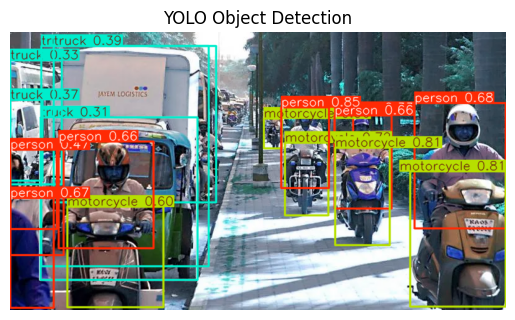

person - 0.85
motorcycle - 0.81
motorcycle - 0.81
motorcycle - 0.72
person - 0.68
person - 0.67
person - 0.66
person - 0.66
motorcycle - 0.60
person - 0.47
person - 0.45
truck - 0.39
truck - 0.37
motorcycle - 0.36
truck - 0.35
person - 0.33
truck - 0.33
truck - 0.31
car - 0.29


In [10]:
#PART 2
#1

!pip install ultralytics


from ultralytics import YOLO
import cv2
from google.colab import files
from PIL import Image
import matplotlib.pyplot as plt

# =========================
# 1. Upload Image
# =========================
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

# =========================
# 2. Load YOLO Model
# =========================
model = YOLO("yolov8n.pt")  # lightweight model

# =========================
# 3. Perform Detection
# =========================
results = model(image_path)

# =========================
# 4. Show Results
# =========================
res_plotted = results[0].plot()

plt.imshow(res_plotted)
plt.axis('off')
plt.title("YOLO Object Detection")
plt.show()

# =========================
# 5. Print Detected Objects
# =========================
for box in results[0].boxes:
    cls_id = int(box.cls[0])
    confidence = float(box.conf[0])
    label = model.names[cls_id]

    print(f"{label} - {confidence:.2f}")

In [11]:
#2q

import numpy as np

# -----------------------------
# 1. IoU Function
# -----------------------------
def compute_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    intersection = max(0, x2 - x1) * max(0, y2 - y1)

    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])

    union = area1 + area2 - intersection

    return intersection / union if union != 0 else 0


# -----------------------------
# 2. Example Ground Truth
# -----------------------------
ground_truths = [
    {"box": [50, 50, 150, 150], "class": "car"},
    {"box": [30, 30, 100, 100], "class": "person"}
]

# -----------------------------
# 3. Example Predictions
# -----------------------------
predictions = [
    {"box": [60, 60, 140, 140], "class": "car", "score": 0.9},
    {"box": [10, 10, 50, 50], "class": "person", "score": 0.6}
]

# Sort predictions by confidence
predictions = sorted(predictions, key=lambda x: x["score"], reverse=True)

# -----------------------------
# 4. Evaluation
# -----------------------------
iou_threshold = 0.5

TP = []
FP = []
matched = [False] * len(ground_truths)

for pred in predictions:
    best_iou = 0
    best_gt_idx = -1

    for i, gt in enumerate(ground_truths):
        if pred["class"] == gt["class"]:
            iou = compute_iou(pred["box"], gt["box"])
            if iou > best_iou:
                best_iou = iou
                best_gt_idx = i

    if best_iou >= iou_threshold and not matched[best_gt_idx]:
        TP.append(1)
        FP.append(0)
        matched[best_gt_idx] = True
    else:
        TP.append(0)
        FP.append(1)

# -----------------------------
# 5. Compute FN
# -----------------------------
FN = matched.count(False)

# -----------------------------
# 6. Precision & Recall
# -----------------------------
TP_cum = np.cumsum(TP)
FP_cum = np.cumsum(FP)

precisions = TP_cum / (TP_cum + FP_cum + 1e-6)
recalls = TP_cum / (len(ground_truths) + 1e-6)

# -----------------------------
# 7. Compute mAP (11-point interpolation)
# -----------------------------
recall_levels = np.linspace(0, 1, 11)
prec_at_recall = []

for r in recall_levels:
    precisions_above_r = precisions[recalls >= r]
    if len(precisions_above_r) > 0:
        prec_at_recall.append(max(precisions_above_r))
    else:
        prec_at_recall.append(0)

mAP = np.mean(prec_at_recall)

# -----------------------------
# 8. Results
# -----------------------------
print("TP:", sum(TP))
print("FP:", sum(FP))
print("FN:", FN)

print("Precision:", precisions[-1])
print("Recall:", recalls[-1])
print("mAP:", mAP)

TP: 1
FP: 1
FN: 1
Precision: 0.499999750000125
Recall: 0.499999750000125
mAP: 0.4545450000004546
